Data Integration
Data integration is the process of combining data from different sources into a single, unified view. It involves merging data from multiple sources and ensuring that the data is consistent and accurate.

The need for data integration arises when organizations have data spread across multiple systems and applications, making it difficult to analyze and gain insights. For example, a company may have customer data stored in a CRM system, sales data stored in a separate database, and marketing data stored in yet another system. Integrating this data can provide a more complete picture of the business and help to identify trends and opportunities.

There are several methods for data integration, including:

Manual integration: This involves manually combining data from different sources into a single dataset. It can be time-consuming and error-prone, but it may be necessary when dealing with small amounts of data or when the data sources are incompatible.
Application programming interface (API) integration: This involves using APIs to extract data from different systems and integrate it into a single dataset. It can be an efficient way to integrate data, but it requires technical expertise to set up and maintain. Python's requests library can be used for making API calls and fetching data from data sources that provide APIs. Other libraries like urllib and http.client can also be used for this purpose.
ETL (extract, transform, load) integration: This involves extracting data from different sources, transforming it to meet the needs of the target system, and loading it into a target database or data warehouse. ETL tools are commonly used to automate this process, making it more efficient and less error-prone. Python has several powerful ETL tools like Apache Nifi, Apache Airflow, and Apache Beam. These tools allow developers to extract data from various sources, perform transformations, and load it into a target database or data warehouse.
Some of the commonly used data integration techniques include concatenation, merging, joining and stacking different datasets. Let's take a thorough look into each of those methods.

In [1]:
import pandas as pd

df1 = pd.DataFrame(
    {"acc" : [13,21,33,48] , "name": ["Ram", "Shyam", "Hari", "Krishna"], "age" : [21,65,34,88]}
)

df2 = pd.DataFrame(
    {"acc" : [13,21,33,48] , "principle": [500, 658, 4032, 500], "interest" : [6.3, 4.25, 9.8, 5.6]}
)

In [2]:
df1, df2

(   acc     name  age
 0   13      Ram   21
 1   21    Shyam   65
 2   33     Hari   34
 3   48  Krishna   88,
    acc  principle  interest
 0   13        500      6.30
 1   21        658      4.25
 2   33       4032      9.80
 3   48        500      5.60)

Concatenation
Concatenation is the process of combining two or more dataframes by appending them along a particular axis. To concatenate two or more dataframes along rows or columns, you can use the pd.concat() function from the pandas library.

In [3]:
pd.concat([df1,df2],axis = 1)

,acc,name,age,acc,principle,interest
0,13,Ram,21,13,500,6.30
1,21,Shyam,65,21,658,4.25
2,33,Hari,34,33,4032,9.80
3,48,Krishna,88,48,500,5.60


In [4]:
pd.concat([df1,df2],axis = 0, ignore_index=True)

,acc,name,age,principle,interest
0,13,Ram,21.0,NaN,NaN
1,21,Shyam,65.0,NaN,NaN
2,33,Hari,34.0,NaN,NaN
3,48,Krishna,88.0,NaN,NaN
4,13,NaN,NaN,500.0,6.30
5,21,NaN,NaN,658.0,4.25
6,33,NaN,NaN,4032.0,9.80
7,48,NaN,NaN,500.0,5.60


Merging
Merging is the process of combining two or more dataframes based on common columns. This technique is used when the datasets have some common columns. You can use the pd.merge() function from the pandas library to merge dataframes.
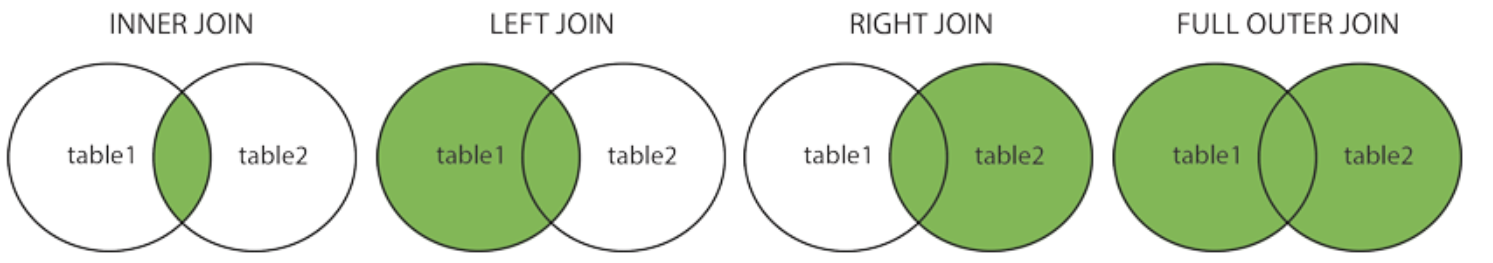

In [5]:
import pandas as pd

df1 = pd.DataFrame(
    {"key" : ["AB", "DH", "AC","DE"] , "name": ["Ram", "Shyam", "Hari", "Krishna"], "age" : [21,65,34,88]}
)

df2 = pd.DataFrame(
    {"key" : ["AB", "CC", "AC","DF"] , "principle": [500, 658, 4032, 500], "age" : [6.3, 4.25, 9.8, 5.6]}
)

In [6]:
df1

,key,name,age
0,AB,Ram,21
1,DH,Shyam,65
2,AC,Hari,34
3,DE,Krishna,88


In [7]:
df2

,key,principle,age
0,AB,500,6.30
1,CC,658,4.25
2,AC,4032,9.80
3,DF,500,5.60


In [8]:
pd.merge(df1, df2, how = "inner", on="key", suffixes=("_df1", "_df2"))

,key,name,age_df1,principle,age_df2
0,AB,Ram,21,500,6.3
1,AC,Hari,34,4032,9.8


In [9]:
pd.merge(df1, df2, how = "outer", on="key", indicator=True)

,key,name,age_x,principle,age_y,_merge
0,AB,Ram,21.0,500.0,6.30,both
1,AC,Hari,34.0,4032.0,9.80,both
2,CC,NaN,NaN,658.0,4.25,right_only
3,DE,Krishna,88.0,NaN,NaN,left_only
4,DF,NaN,NaN,500.0,5.60,right_only
5,DH,Shyam,65.0,NaN,NaN,left_only


Two datasets from different vendors:

vendor_a.csv: product_id, price -> df1

vendor_b.csv: product_id, stock -> df2

Questions:

Which merge type keeps only products present in both datasets? -> Inner
How would you keep all products from both vendors? -> Outer
How can you identify products that exist only in one source? -> left / right

After merging two DataFrames, you notice unexpected row duplication.

Questions:

What does this indicate about the merge keys? -> If we have duplicate keys
How can you detect duplicate keys before merging? -> valiadate parameter
Which pandas argument helps track the source of each row after merging? -> indicator parameter

In [10]:
# Alternative Syntax

df1.merge(df2, on = "key", how = "inner")

,key,name,age_x,principle,age_y
0,AB,Ram,21,500,6.3
1,AC,Hari,34,4032,9.8


Scenario 1: Index Joins & Data Type Mismatches
user_logs.csv: user_id (Index), action, timestamp 
 df_logs

user_info.csv: user_id (Column), age, city 
 df_info

How do you merge when the key is an Index in one DataFrame and a standard Column in the other?
Answer: Use left_index=True (or right_index=True) alongside right_on='user_id' (or left_on).
Syntax: pd.merge(df_logs, df_info, left_index=True, right_on='user_id')
If user_id is an integer in df_logs but a string in df_info, what happens during a merge, and how do you resolve it?
Answer: Pandas will treat integer 101 and string '101' as distinct keys, resulting in an empty DataFrame or missed matches. Cast them to matching data types prior to merging.
Syntax: df_info['user_id'] = df_info['user_id'].astype(int)
Scenario 2: Multi-Key Merges & Non-Standard Matching
daily_sales.csv: store_id, item_id, units_sold 
 df_sales

inventory.csv: store_id, item_id, stock_level 
 df_inventory

How do you perform a merge across multiple matching key columns at once?
Answer: Pass a list of column names to the on parameter.
Syntax: pd.merge(df_sales, df_inventory, on=['store_id', 'item_id'])
By default, pandas ignores key pairs where a key contains NaN. Which argument allows you to treat NaN values as equal and match them across DataFrames?
Answer: dropna=False
Syntax: pd.merge(df_sales, df_inventory, on=['store_id', 'item_id'], dropna=False)

Joining
Joining is similar to merging, but is specifically used to combine dataframes based on their indexes. You can use the pd.DataFrame.join() method to join dataframes.

In [11]:
df1.set_index("key", inplace = True)
df1

,name,age
key,,
AB,Ram,21
DH,Shyam,65
AC,Hari,34
DE,Krishna,88


In [12]:
df2.set_index("key", inplace = True)
df2

,principle,age
key,,
AB,500,6.30
CC,658,4.25
AC,4032,9.80
DF,500,5.60


In [13]:
df1.join(df2, how = "inner", lsuffix="_left")

,name,age_left,principle,age
key,,,,
AB,Ram,21,500,6.3
AC,Hari,34,4032,9.8



Stacking
Stacking is the process of vertically combining datasets with the same columns. The datasets are aligned by their column names and then stacked on top of each other. You can use the dataframe.stack() function to stack a dataframe.

In [14]:
df1

,name,age
key,,
AB,Ram,21
DH,Shyam,65
AC,Hari,34
DE,Krishna,88


In [15]:
stacked = df1.stack()
stacked

key      
AB   name        Ram
     age          21
DH   name      Shyam
     age          65
AC   name       Hari
     age          34
DE   name    Krishna
     age          88
dtype: object

In [16]:
stacked.unstack()

,name,age
key,,
AB,Ram,21
DH,Shyam,65
AC,Hari,34
DE,Krishna,88
